# Lab 4 - Dynamic Programming: Dijkstra vs Floyd-Warshall

## Subject
Dynamic programming for shortest paths in weighted directed graphs.

## Objectives
1. Study dynamic programming as an algorithm design method.
2. Implement **Dijkstra** and **Floyd-Warshall** in Python.
3. Do empirical analysis on **sparse** and **dense** graphs.
4. Increase graph size (few vs many nodes), measure impact, and present results graphically.
5. Produce a concise report with practical recommendations.

## Notes
- We test several graph families used in Lab 3 where applicable: simple/random, complete, wheel, bipartite, regular, planar grid, tree, cyclic, weighted.
- For shortest paths, we use positive weights (required by Dijkstra).

In [37]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [38]:
import math
import random
import time
import heapq
from statistics import mean

import matplotlib.pyplot as plt

random.seed(42)
INF = float("inf")

plt.style.use("seaborn-v0_8-whitegrid")

In [39]:
def _add_undirected_weighted_edge(edge_map, u, v, w):
    if u == v:
        return
    key1 = (u, v)
    key2 = (v, u)
    if key1 not in edge_map or w < edge_map[key1]:
        edge_map[key1] = w
    if key2 not in edge_map or w < edge_map[key2]:
        edge_map[key2] = w


def build_graph_structures(n, edge_map):
    adj = [[] for _ in range(n)]
    matrix = [[INF] * n for _ in range(n)]
    for i in range(n):
        matrix[i][i] = 0

    for (u, v), w in edge_map.items():
        adj[u].append((v, w))
        if w < matrix[u][v]:
            matrix[u][v] = w

    m = len(edge_map)
    density = m / (n * (n - 1)) if n > 1 else 0.0
    return adj, matrix, m, density


def generate_random_weighted_digraph(n, density, w_min=1, w_max=20):
    edge_map = {}
    for u in range(n):
        for v in range(n):
            if u != v and random.random() < density:
                edge_map[(u, v)] = random.randint(w_min, w_max)
    return build_graph_structures(n, edge_map)


def generate_graph_family(n, family, density=0.3, w_min=1, w_max=20):
    edge_map = {}

    if family == "simple":
        return generate_random_weighted_digraph(n, density, w_min, w_max)

    if family == "complete":
        for u in range(n):
            for v in range(n):
                if u != v:
                    edge_map[(u, v)] = random.randint(w_min, w_max)
        return build_graph_structures(n, edge_map)

    if family == "cycle":
        for u in range(n):
            v = (u + 1) % n
            _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "tree":
        for v in range(1, n):
            parent = random.randint(0, v - 1)
            _add_undirected_weighted_edge(edge_map, parent, v, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "wheel":
        if n < 4:
            return generate_graph_family(n, "cycle", density, w_min, w_max)
        center = 0
        rim = list(range(1, n))
        for i in range(len(rim)):
            u = rim[i]
            v = rim[(i + 1) % len(rim)]
            _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
            _add_undirected_weighted_edge(edge_map, center, u, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "bipartite":
        left = list(range(n // 2))
        right = list(range(n // 2, n))
        p = min(1.0, max(0.05, density))
        for u in left:
            for v in right:
                if random.random() < p:
                    _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "regular":
        k = max(2, min(6, n - 1))
        if k % 2 == 1:
            k -= 1
        for u in range(n):
            for shift in range(1, k // 2 + 1):
                v = (u + shift) % n
                _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "grid":
        side = int(math.sqrt(n))
        side = max(2, side)
        n_grid = side * side
        for r in range(side):
            for c in range(side):
                u = r * side + c
                if c + 1 < side:
                    v = r * side + (c + 1)
                    _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
                if r + 1 < side:
                    v = (r + 1) * side + c
                    _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
        return build_graph_structures(n_grid, edge_map)

    if family == "weighted":
        return generate_random_weighted_digraph(n, density, w_min, w_max)

    raise ValueError(f"Unknown family: {family}")

In [40]:
def dijkstra_single_source(adj, src):
    n = len(adj)
    dist = [INF] * n
    dist[src] = 0
    pq = [(0, src)]

    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, w in adj[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))

    return dist


def all_pairs_dijkstra(adj):
    return [dijkstra_single_source(adj, s) for s in range(len(adj))]


def floyd_warshall(matrix):
    n = len(matrix)
    dist = [row[:] for row in matrix]

    for k in range(n):
        dk = dist[k]
        for i in range(n):
            dik = dist[i][k]
            if dik == INF:
                continue
            di = dist[i]
            base = dik
            for j in range(n):
                alt = base + dk[j]
                if alt < di[j]:
                    di[j] = alt

    return dist


def same_distance_matrices(a, b, eps=1e-9):
    if len(a) != len(b):
        return False
    n = len(a)
    for i in range(n):
        for j in range(n):
            x, y = a[i][j], b[i][j]
            both_inf = (x == INF and y == INF)
            if both_inf:
                continue
            if abs(x - y) > eps:
                return False
    return True

In [41]:
def time_function(fn, *args, repeats=3, **kwargs):
    times = []
    result = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn(*args, **kwargs)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return mean(times), result


def benchmark_case(adj, matrix, repeats=3, validate=False):
    dijkstra_t, dijkstra_dist = time_function(all_pairs_dijkstra, adj, repeats=repeats)
    floyd_t, floyd_dist = time_function(floyd_warshall, matrix, repeats=repeats)

    ok = None
    if validate:
        ok = same_distance_matrices(dijkstra_dist, floyd_dist)

    return {
        "dijkstra_s": dijkstra_t,
        "floyd_s": floyd_t,
        "speedup_d_over_f": (floyd_t / dijkstra_t) if dijkstra_t > 0 else INF,
        "correct": ok,
    }


def run_scale_experiment(node_sizes, densities, repeats=2):
    rows = []
    for density in densities:
        for n in node_sizes:
            adj, matrix, m, real_density = generate_random_weighted_digraph(n, density)
            bench = benchmark_case(adj, matrix, repeats=repeats, validate=(n <= 80))
            rows.append({
                "family": "simple",
                "n": n,
                "m": m,
                "density": real_density,
                "target_density": density,
                **bench,
            })
    return rows


def run_family_experiment(n=80, density=0.3, repeats=2):
    families = ["simple", "complete", "wheel", "bipartite", "regular", "grid", "tree", "cycle", "weighted"]
    rows = []
    for fam in families:
        adj, matrix, m, real_density = generate_graph_family(n, fam, density=density)
        n_eff = len(adj)
        bench = benchmark_case(adj, matrix, repeats=repeats, validate=(n_eff <= 100))
        rows.append({
            "family": fam,
            "n": n_eff,
            "m": m,
            "density": real_density,
            **bench,
        })
    return rows

In [45]:
node_sizes = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 250, 300]
densities = [0.1, 0.3, 0.6, 0.8, 0.9]

scale_rows = run_scale_experiment(node_sizes=node_sizes, densities=densities, repeats=2)
family_rows = run_family_experiment(n=80, density=0.35, repeats=2)

print(f"Scale experiment rows: {len(scale_rows)}")
print(f"Family experiment rows: {len(family_rows)}")

correct_checks_scale = [r["correct"] for r in scale_rows if r["correct"] is not None]
correct_checks_family = [r["correct"] for r in family_rows if r["correct"] is not None]

if correct_checks_scale or correct_checks_family:
    all_correct = all(correct_checks_scale + correct_checks_family)
    print("Correctness check (where enabled):", "PASS" if all_correct else "FAIL")

sample = scale_rows[:4]
for r in sample:
    winner = "Dijkstra" if r["dijkstra_s"] <= r["floyd_s"] else "Floyd-Warshall"
    print(f"n={r['n']:3d}, density~{r['density']:.2f}, D={r['dijkstra_s']:.4f}s, F={r['floyd_s']:.4f}s -> {winner}")

Scale experiment rows: 60
Family experiment rows: 9
Correctness check (where enabled): PASS
n= 20, density~0.08, D=0.0002s, F=0.0005s -> Dijkstra
n= 40, density~0.10, D=0.0034s, F=0.0082s -> Dijkstra
n= 60, density~0.10, D=0.0078s, F=0.0322s -> Dijkstra
n= 80, density~0.10, D=0.0184s, F=0.0533s -> Dijkstra


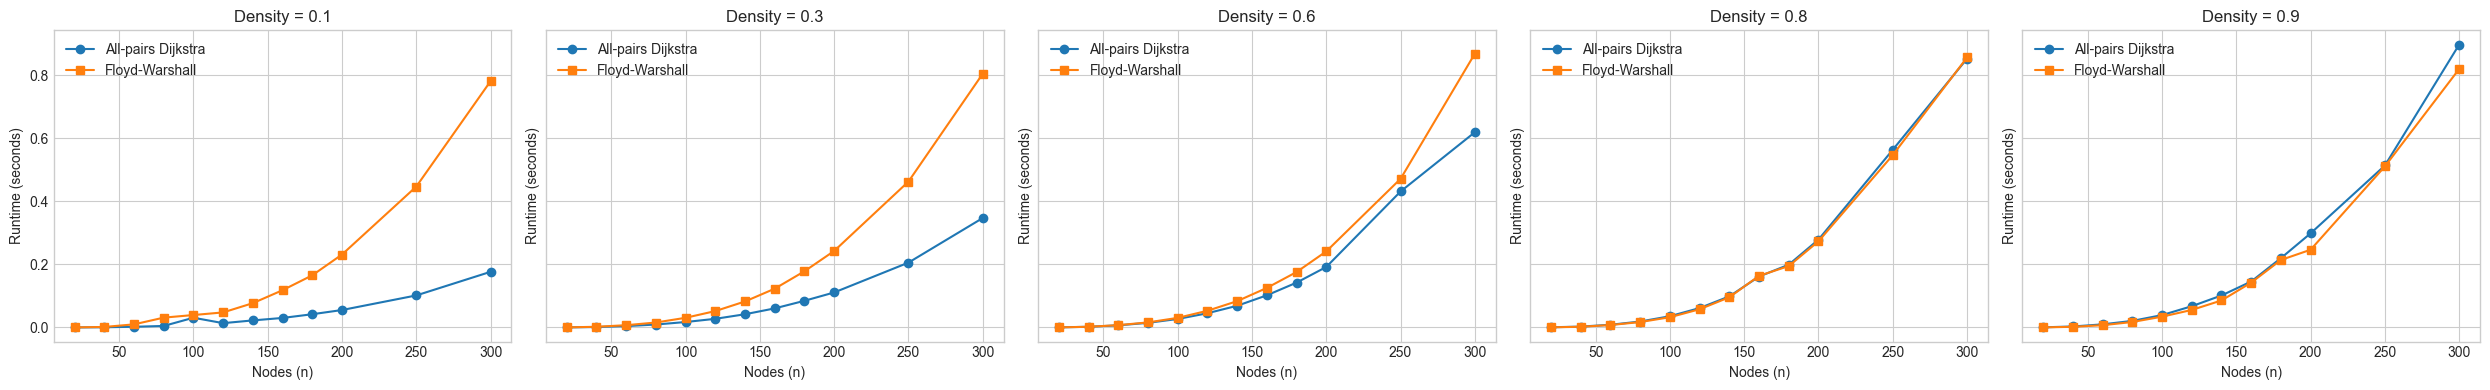

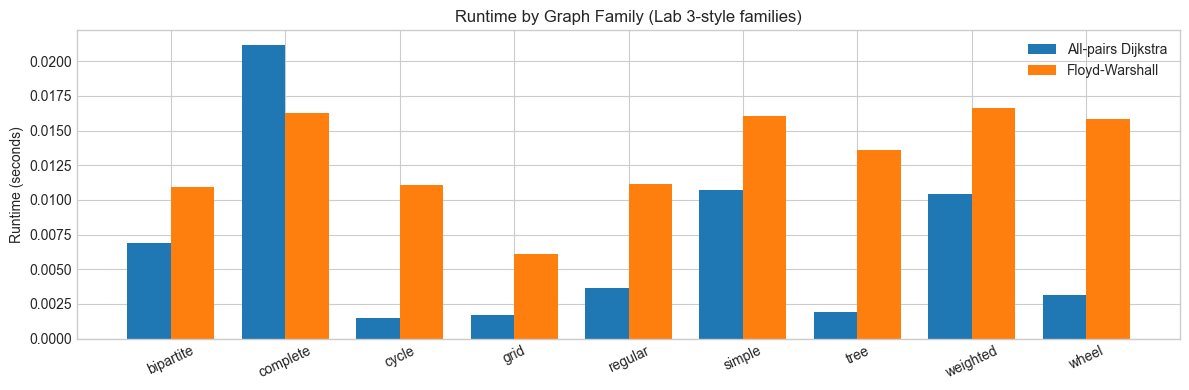

In [43]:
def filter_rows(rows, target_density):
    return [r for r in rows if abs(r["target_density"] - target_density) < 1e-12]


def plot_scale_curves(rows, densities):
    fig, axes = plt.subplots(1, len(densities), figsize=(5 * len(densities), 4), sharey=True)
    if len(densities) == 1:
        axes = [axes]

    for ax, d in zip(axes, densities):
        sub = sorted(filter_rows(rows, d), key=lambda x: x["n"])
        xs = [r["n"] for r in sub]
        yd = [r["dijkstra_s"] for r in sub]
        yf = [r["floyd_s"] for r in sub]

        ax.plot(xs, yd, marker="o", label="All-pairs Dijkstra")
        ax.plot(xs, yf, marker="s", label="Floyd-Warshall")
        ax.set_title(f"Density = {d}")
        ax.set_xlabel("Nodes (n)")
        ax.set_ylabel("Runtime (seconds)")
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_family_bars(rows):
    rows = sorted(rows, key=lambda x: x["family"])
    labels = [r["family"] for r in rows]
    yd = [r["dijkstra_s"] for r in rows]
    yf = [r["floyd_s"] for r in rows]

    x = list(range(len(labels)))
    w = 0.38

    plt.figure(figsize=(12, 4))
    plt.bar([i - w / 2 for i in x], yd, width=w, label="All-pairs Dijkstra")
    plt.bar([i + w / 2 for i in x], yf, width=w, label="Floyd-Warshall")
    plt.xticks(x, labels, rotation=25)
    plt.ylabel("Runtime (seconds)")
    plt.title("Runtime by Graph Family (Lab 3-style families)")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_scale_curves(scale_rows, densities)
plot_family_bars(family_rows)

In [46]:
def winner(row):
    return "Dijkstra" if row["dijkstra_s"] <= row["floyd_s"] else "Floyd-Warshall"


def accuracy_for_density_cut(rows, density_cut):
    ok = 0
    for r in rows:
        pred = "Floyd-Warshall" if r["density"] >= density_cut else "Dijkstra"
        if pred == winner(r):
            ok += 1
    return ok / len(rows)


def summarize_wins_by_target_density(rows):
    buckets = {}
    for r in rows:
        d = r["target_density"]
        if d not in buckets:
            buckets[d] = {"Dijkstra": 0, "Floyd-Warshall": 0, "total": 0}
        w = winner(r)
        buckets[d][w] += 1
        buckets[d]["total"] += 1
    return buckets


def fit_density_only_rule(rows):
    density_targets = sorted({r["target_density"] for r in rows})
    cuts = [0.0]
    for i in range(len(density_targets) - 1):
        cuts.append((density_targets[i] + density_targets[i + 1]) / 2)
    cuts.extend(density_targets)

    best = {"acc": -1.0, "density_cut": 1.0}
    for cut in cuts:
        acc = accuracy_for_density_cut(rows, cut)
        if acc > best["acc"]:
            best = {"acc": acc, "density_cut": cut}
    return best


def recommend(n, m, density_cut=0.80):
    density = m / (n * (n - 1)) if n > 1 else 0.0
    return "Floyd-Warshall" if density >= density_cut else "Dijkstra"


wins = summarize_wins_by_target_density(scale_rows)
learned_density = fit_density_only_rule(scale_rows)
acc_080 = accuracy_for_density_cut(scale_rows, 0.80)

print("Winner distribution by target density:")
for d in sorted(wins):
    b = wins[d]
    print(f"- density={d:.2f}: Dijkstra={b['Dijkstra']}, Floyd={b['Floyd-Warshall']}")

print("\nDensity-only learned cutoff (best on measured grid):")
print(f"- Best cutoff: density >= {learned_density['density_cut']:.2f} -> Floyd-Warshall")
print(f"- Accuracy: {learned_density['acc'] * 100:.1f}%")

print("\nSimple practical rule (your suggestion):")
print("- If density < 0.80: use Dijkstra")
print("- If density >= 0.80: use Floyd-Warshall")
print(f"- Accuracy on benchmark grid: {acc_080 * 100:.1f}%")

# Example requested in statement style
n_example = 90
density_example = 0.6
m_example = int(density_example * n_example * (n_example - 1))
print(f"\nExample: n={n_example}, density={density_example} -> {recommend(n_example, m_example, 0.80)}")

Winner distribution by target density:
- density=0.10: Dijkstra=12, Floyd=0
- density=0.30: Dijkstra=12, Floyd=0
- density=0.60: Dijkstra=10, Floyd=2
- density=0.80: Dijkstra=3, Floyd=9
- density=0.90: Dijkstra=0, Floyd=12

Density-only learned cutoff (best on measured grid):
- Best cutoff: density >= 0.70 -> Floyd-Warshall
- Accuracy: 91.7%

Simple practical rule (your suggestion):
- If density < 0.80: use Dijkstra
- If density >= 0.80: use Floyd-Warshall
- Accuracy on benchmark grid: 88.3%

Example: n=90, density=0.6 -> Dijkstra


## Short Report Template (Fill after execution)

### 1) Dynamic programming method
- Floyd-Warshall is a classic dynamic programming algorithm for all-pairs shortest paths.
- Dijkstra (single-source) is applied repeatedly for all sources to compare all-pairs performance.

### 2) Implemented algorithms
- All-pairs Dijkstra using a min-heap (`O(n * (m log n))` on adjacency lists).
- Floyd-Warshall (`O(n^3)`) on adjacency matrix.

### 3) Sparse vs dense empirical analysis
- Use the generated runtime plots.
- Compare the growth trend when density increases from sparse to dense.

### 4) Influence of node count
- Use the runtime-vs-n curves for each density.
- Identify the break-even point (if any) where Floyd-Warshall becomes competitive.

### 5) Final recommendation
- Use the printed learned rule based on `(n, m)` / density.
- Mention rule accuracy over the measured benchmark grid.